Fetching weather data...

   h | Season                 |   RMSE |    MAE | Baseline |  Improv.
---------------------------------------------------------------------------
   1h | Winter (January)       |  0.641 |  0.450 |    0.744 |    13.9%
   1h | Summer (July)          |  0.700 |  0.425 |    0.960 |    27.1%
   3h | Winter (January)       |  1.604 |  1.225 |    1.790 |    10.4%
   3h | Summer (July)          |  1.320 |  0.955 |    2.367 |    44.2%
   6h | Winter (January)       |  2.629 |  2.038 |    2.990 |    12.1%
   6h | Summer (July)          |  1.814 |  1.360 |    4.089 |    55.6%
  12h | Winter (January)       |  3.615 |  2.893 |    4.556 |    20.7%
  12h | Summer (July)          |  2.286 |  1.759 |    5.700 |    59.9%
  24h | Winter (January)       |  4.614 |  3.723 |    5.971 |    22.7%
  24h | Summer (July)          |  2.506 |  1.974 |    3.217 |    22.1%
  48h | Winter (January)       |  5.471 |  4.421 |    6.964 |    21.4%
  48h | Summer (July)          |  2.977 |  2.38

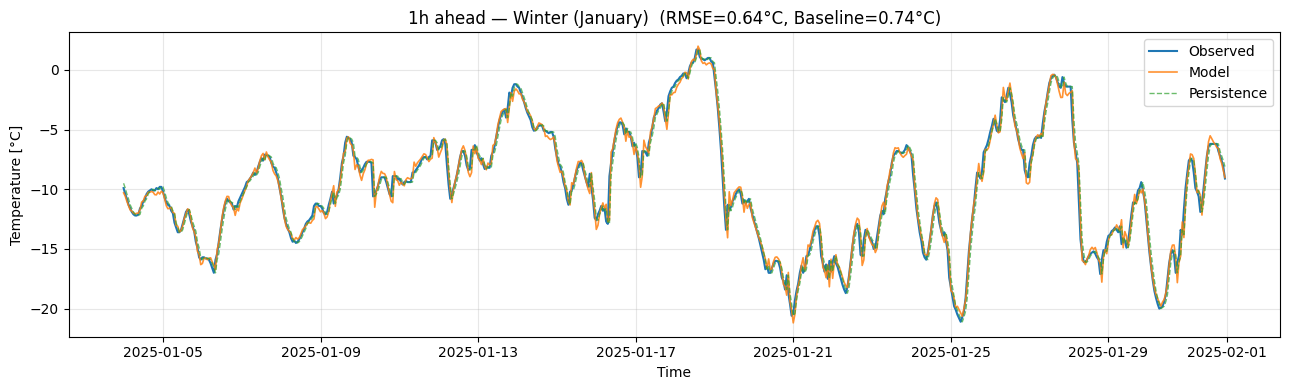

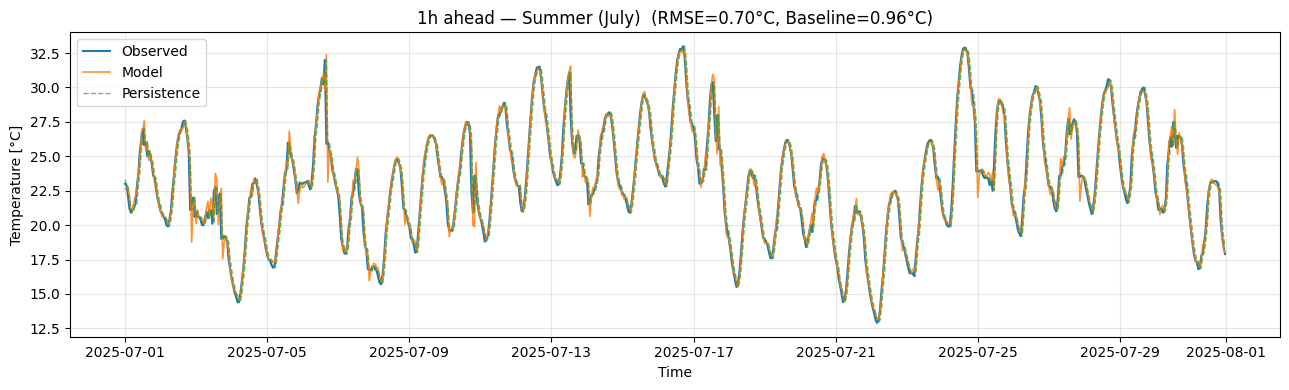

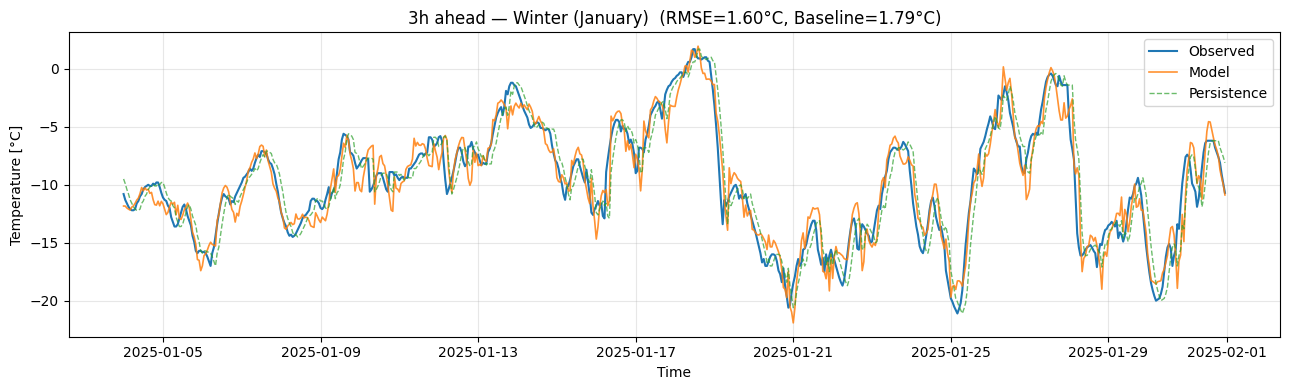

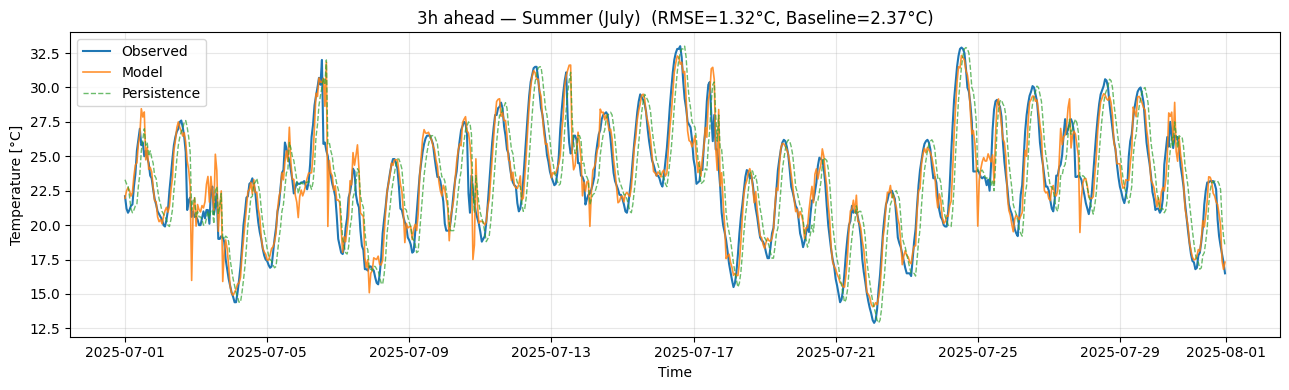

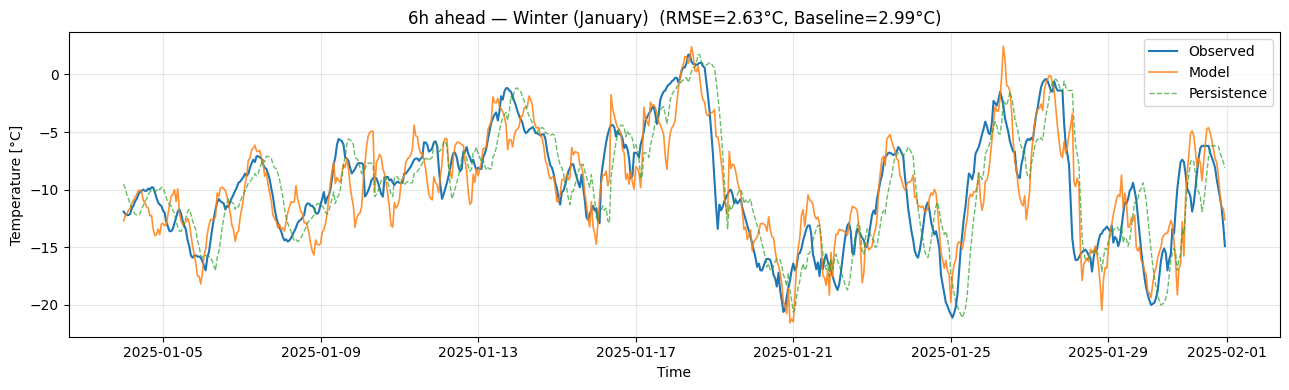

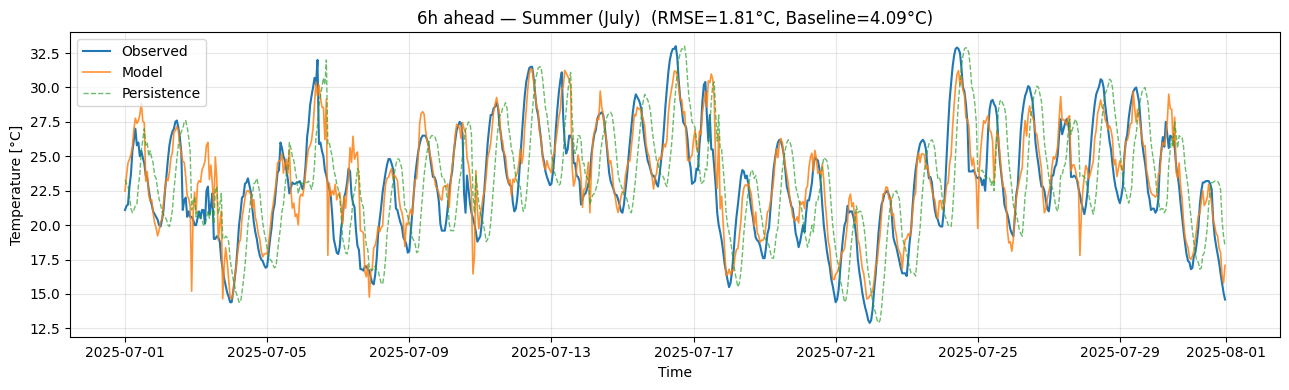

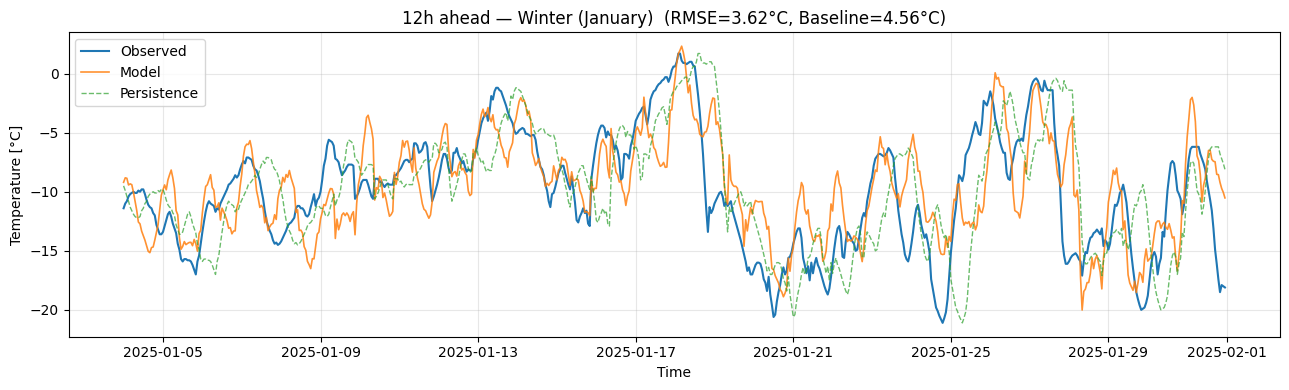

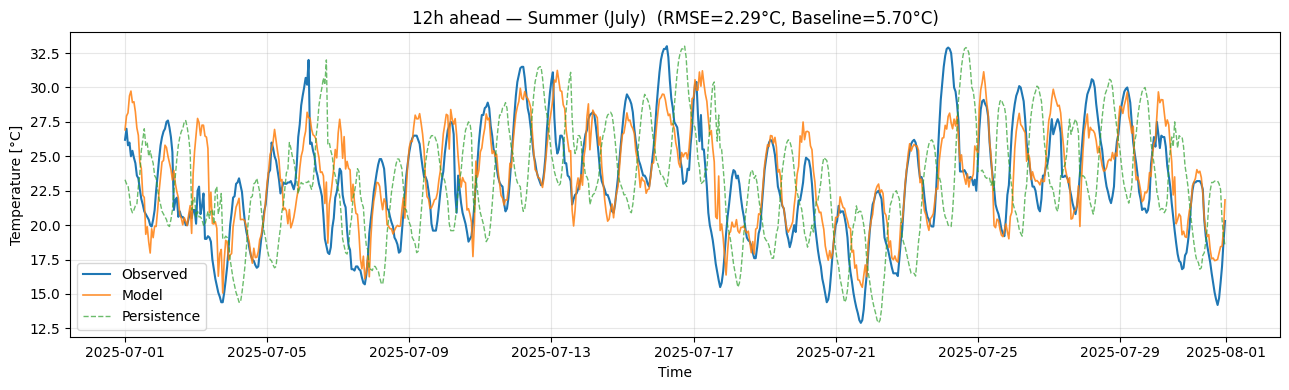

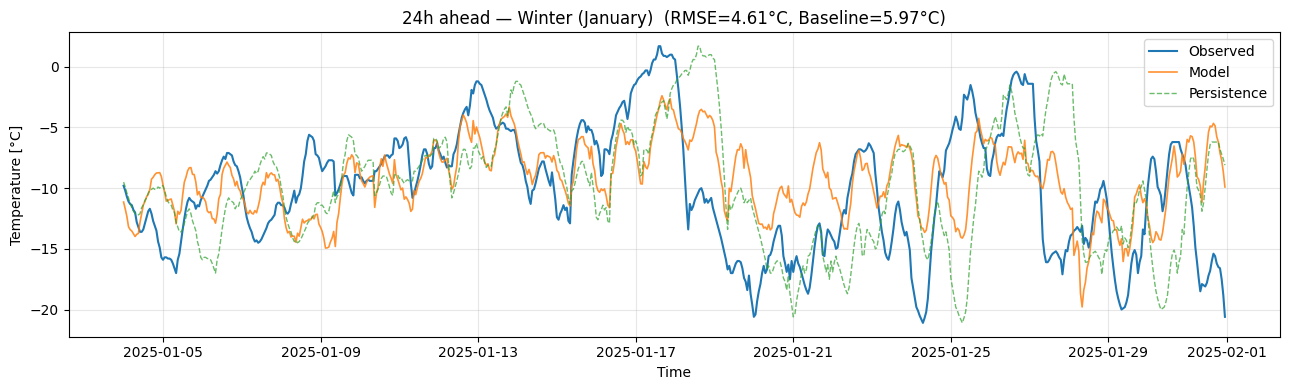

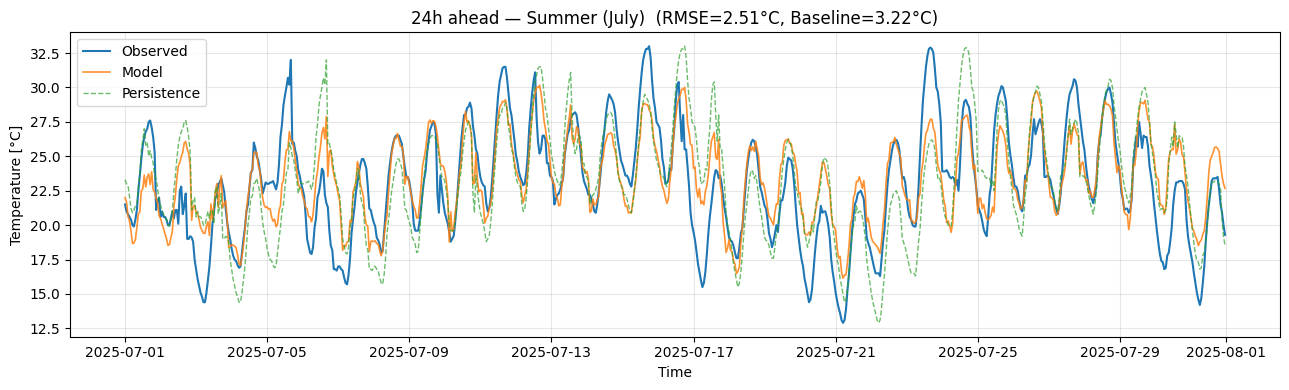

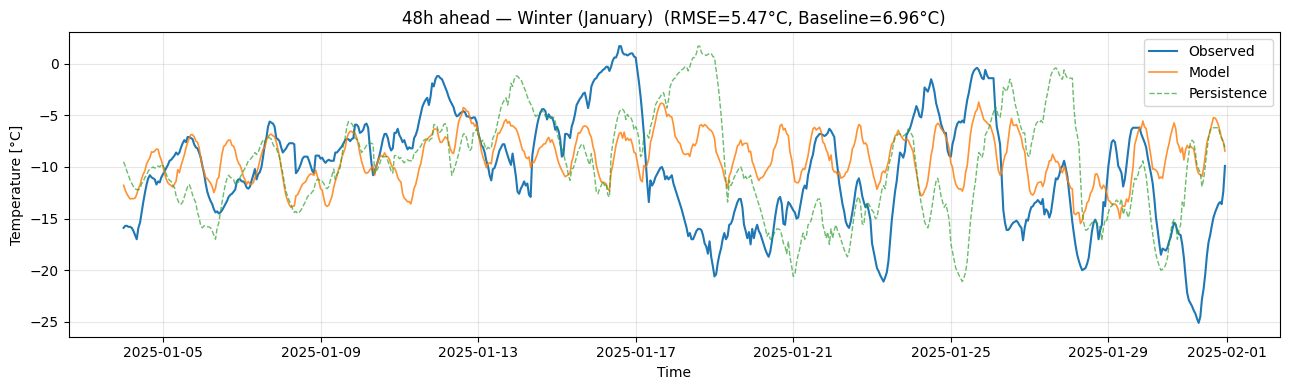

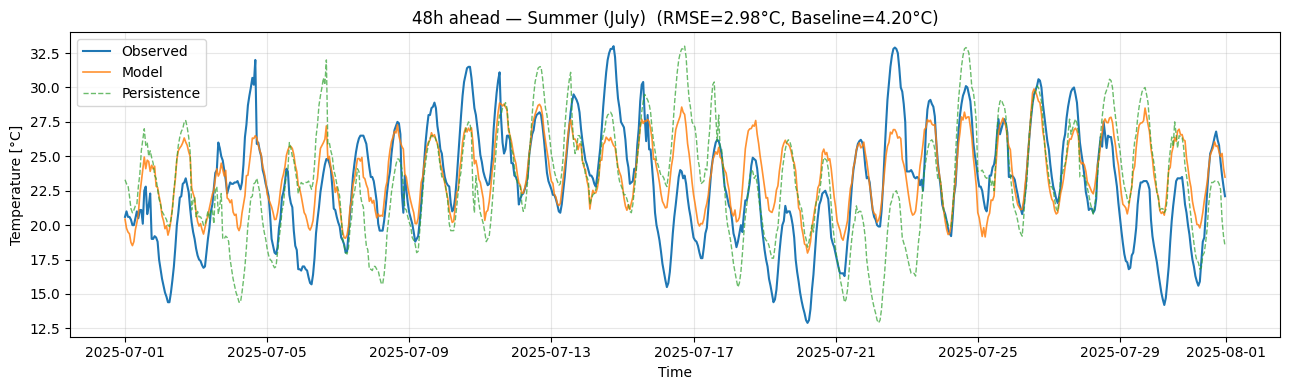

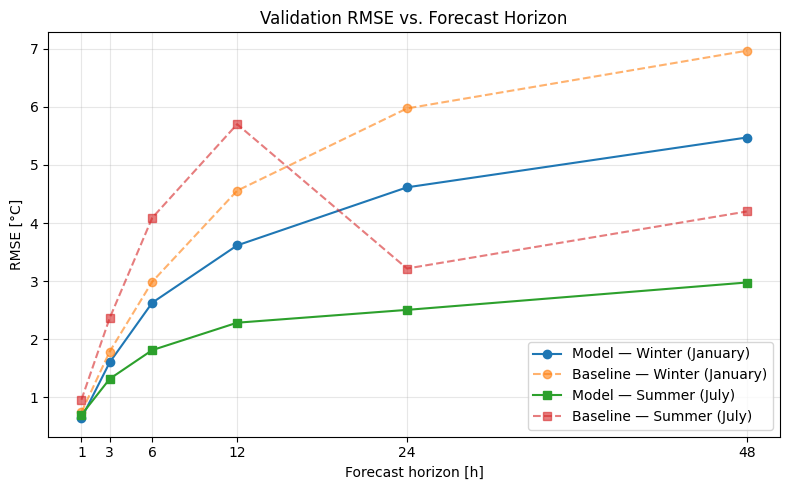

In [ ]:
# ================================
# MECH 309 - Part 1
# Multi-horizon temperature prediction
# Horizons: 1h, 3h, 6h, 12h, 24h, 48h
# Seasonal validation: winter + summer
#
# Modeling strategy:
# - use a ridge regression model fit by least squares
# - predict future temperature from current conditions,
#   lagged variables, and periodic time features
# - features are standardized before fitting for numerical stability
# - evaluate separately in winter and summer to test
#   generalization across different weather regimes
# ================================

from __future__ import annotations
import math
from dataclasses import dataclass
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt


# -------------------------------
# Location definition
# -------------------------------
@dataclass(frozen=True)
class Location:
    name: str
    lat: float
    lon: float
    timezone: str


MONTREAL = Location(
    name="Montreal, QC",
    lat=45.5017,
    lon=-73.5673,
    timezone="America/Montreal",
)


# --------------------------------
# Data acquisition
# --------------------------------

def fetch_open_meteo_hourly(start_date: str, end_date: str, location: Location = MONTREAL) -> pd.DataFrame:
    """
    Download hourly weather data from Open-Meteo archive API.

    Variables:
    - T     : 2m air temperature [°C]
    - W     : 10m wind speed [km/h]
    - RH    : relative humidity [%]
    - P     : surface pressure [hPa]
    - Cloud : cloud cover [%]
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": location.lat,
        "longitude": location.lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join([
            "temperature_2m",
            "wind_speed_10m",
            "relative_humidity_2m",
            "surface_pressure",
            "cloud_cover",
        ]),
        "timezone": location.timezone,
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()

    hourly = payload["hourly"]
    idx = pd.to_datetime(hourly["time"])

    df = pd.DataFrame(index=idx)
    df["T"]     = hourly["temperature_2m"]
    df["W"]     = hourly["wind_speed_10m"]
    df["RH"]    = hourly["relative_humidity_2m"]
    df["P"]     = hourly["surface_pressure"]
    df["Cloud"] = hourly["cloud_cover"]
    df.index.name = "time_local"
    return df


# --------------------------------
# Preprocessing
# --------------------------------

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean the raw weather DataFrame and add periodic time features.

    Steps:
    1. Sort and de-duplicate the time index.
    2. Reindex to a complete hourly grid to ensure every lag is valid.
    3. Fill short gaps by interpolation, then forward/back-fill endpoints.
    4. Encode time-of-day and day-of-year as sine/cosine pairs so the
       representation is cyclic and the model can learn daily and seasonal patterns.
    """
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]

    full_idx = pd.date_range(df.index.min(), df.index.max(), freq="h", tz=df.index.tz)
    df = df.reindex(full_idx)
    df = df.interpolate(limit=6).ffill().bfill()

    hour = df.index.hour.to_numpy()
    doy  = df.index.dayofyear.to_numpy()

    df["sin_day"]  = np.sin(2 * math.pi / 24    * hour)
    df["cos_day"]  = np.cos(2 * math.pi / 24    * hour)
    df["sin_year"] = np.sin(2 * math.pi / 365.25 * doy)
    df["cos_year"] = np.cos(2 * math.pi / 365.25 * doy)

    return df


# --------------------------------
# Lagged predictors
# --------------------------------

def add_lags(df: pd.DataFrame, col: str, lags: list[int]) -> pd.DataFrame:
    """Add lagged copies of `col` as new columns."""
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)
    return df


# --------------------------------
# Error metrics
# --------------------------------

def rmse(y: np.ndarray, yhat: np.ndarray) -> float:
    """Root-mean-square error — penalises large deviations strongly."""
    return float(np.sqrt(np.mean((y - yhat) ** 2)))


def mae(y: np.ndarray, yhat: np.ndarray) -> float:
    """Mean absolute error — directly interpretable in °C."""
    return float(np.mean(np.abs(y - yhat)))


# --------------------------------
# Feature scaling
# --------------------------------

def fit_scaler(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute column-wise mean and standard deviation on training data.

    Standardizing features (zero mean, unit variance) is important here
    because the predictors span very different numerical ranges
    (e.g. pressure ~1000 hPa vs cloud cover 0–100). Without scaling,
    the least-squares problem can become ill-conditioned and ridge
    regularization becomes inconsistent across features.
    """
    mu  = X.mean(axis=0)
    sig = X.std(axis=0)
    sig[sig == 0] = 1.0          # avoid division by zero for constant columns
    return mu, sig


def apply_scaler(X: np.ndarray, mu: np.ndarray, sig: np.ndarray) -> np.ndarray:
    """Apply pre-computed standardization to a feature matrix."""
    return (X - mu) / sig


# --------------------------------
# Seasonal split
# --------------------------------

def seasonal_split(
    df: pd.DataFrame, year: int, month: int
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Hold out one calendar month as the validation set.
    All remaining months form the training set.
    """
    val_mask = (df.index.year == year) & (df.index.month == month)
    return df.loc[~val_mask].copy(), df.loc[val_mask].copy()


# --------------------------------
# Model training
# --------------------------------

def fit_ridge(
    X_train: np.ndarray,
    y_train: np.ndarray,
    alpha: float = 0.1,
) -> np.ndarray:
    """
    Fit ridge regression: minimise ||X theta - y||^2 + alpha * ||theta||^2.

    Ridge (L2) regularization shrinks coefficients toward zero, which
    reduces overfitting when many correlated lagged features are used.
    The normal equations for ridge are:

        theta = (X^T X + alpha * I)^{-1} X^T y

    Using np.linalg.solve is numerically more stable than matrix inversion.

    Parameters
    ----------
    alpha : regularization strength (0 = ordinary least squares)
    """
    n_features = X_train.shape[1]
    A = X_train.T @ X_train + alpha * np.eye(n_features)
    b = X_train.T @ y_train
    theta = np.linalg.solve(A, b)
    return theta


# --------------------------------
# Single model run
# --------------------------------

def run_model_for_month(
    df_base: pd.DataFrame,
    h: int,
    feature_cols: list[str],
    year: int,
    month: int,
    month_name: str,
    alpha: float = 0.1,
) -> dict:
    """
    Train and evaluate one model for a given forecast horizon and validation month.

    The target at time k is T(k + h), constructed by shifting the temperature
    column backward by h steps so that each row uses only past information.

    Returns a dict with metrics, predictions, and named model coefficients.
    """
    df = df_base.copy()
    df["T_target"] = df["T"].shift(-h)
    df = df.dropna().copy()

    train_df, val_df = seasonal_split(df, year, month)

    X_train_raw = train_df[feature_cols].to_numpy()
    y_train     = train_df["T_target"].to_numpy()
    X_val_raw   = val_df[feature_cols].to_numpy()
    y_val       = val_df["T_target"].to_numpy()

    # --- Standardize features (fit on training data only) ---
    mu, sig = fit_scaler(X_train_raw)
    X_train = apply_scaler(X_train_raw, mu, sig)
    X_val   = apply_scaler(X_val_raw,   mu, sig)

    # --- Add intercept column after scaling ---
    X_train = np.column_stack([np.ones(len(X_train)), X_train])
    X_val   = np.column_stack([np.ones(len(X_val)),   X_val])

    # --- Fit ridge regression ---
    theta = fit_ridge(X_train, y_train, alpha=alpha)

    # --- Predictions ---
    yhat_train = X_train @ theta
    yhat_val   = X_val   @ theta

    # --- Persistence baseline: T_{k+h} ≈ T_k ---
    baseline = val_df["T"].to_numpy()

    # --- Named coefficients for report ---
    coef_names  = ["intercept"] + feature_cols
    coefficients = dict(zip(coef_names, theta))

    return {
        "h":            h,
        "month_name":   month_name,
        "train_rmse":   rmse(y_train,  yhat_train),
        "val_rmse":     rmse(y_val,    yhat_val),
        "val_mae":      mae(y_val,     yhat_val),
        "baseline_rmse": rmse(y_val,   baseline),
        "val_index":    val_df.index,
        "y_val":        y_val,
        "yhat":         yhat_val,
        "baseline":     baseline,
        "coefficients": coefficients,
    }


# --------------------------------
# Reporting helpers
# --------------------------------

def print_results(results: list[dict]) -> None:
    """Print a formatted results table to stdout."""
    print("\n" + "=" * 75)
    print(f"{'h':>4} | {'Season':<22} | {'RMSE':>6} | {'MAE':>6} | {'Baseline':>8} | {'Improv.':>8}")
    print("-" * 75)
    for r in results:
        improvement = 100 * (r["baseline_rmse"] - r["val_rmse"]) / r["baseline_rmse"]
        print(
            f"{r['h']:>4}h | {r['month_name']:<22} | "
            f"{r['val_rmse']:>6.3f} | {r['val_mae']:>6.3f} | "
            f"{r['baseline_rmse']:>8.3f} | {improvement:>7.1f}%"
        )
    print("=" * 75)


def save_results_table(results: list[dict], path: str = "results_table.csv") -> pd.DataFrame:
    """Save RMSE/MAE summary to a CSV for inclusion in the report."""
    rows = []
    for r in results:
        improvement = 100 * (r["baseline_rmse"] - r["val_rmse"]) / r["baseline_rmse"]
        rows.append({
            "Horizon (h)":        r["h"],
            "Season":             r["month_name"],
            "Train RMSE (°C)":    round(r["train_rmse"],   3),
            "Val RMSE (°C)":      round(r["val_rmse"],     3),
            "Val MAE (°C)":       round(r["val_mae"],      3),
            "Baseline RMSE (°C)": round(r["baseline_rmse"], 3),
            "Improvement (%)":    round(improvement,       1),
        })
    table = pd.DataFrame(rows)
    table.to_csv(path, index=False)
    print(f"\nResults table saved to: {path}")
    return table


def print_coefficients(result: dict, top_n: int = 10) -> None:
    """Print the top-N most influential coefficients (by absolute value)."""
    coefs = result["coefficients"]
    sorted_coefs = sorted(coefs.items(), key=lambda x: abs(x[1]), reverse=True)
    print(f"\nTop {top_n} coefficients for h={result['h']}h — {result['month_name']}:")
    for name, val in sorted_coefs[:top_n]:
        print(f"  {name:<20s}: {val:+.4f}")


# --------------------------------
# Plotting
# --------------------------------

def plot_predictions(results: list[dict], save: bool = False) -> None:
    """
    Plot true temperature, model prediction, and persistence baseline
    for each horizon/season combination.
    """
    for r in results:
        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(r["val_index"], r["y_val"],   label="Observed",    lw=1.5)
        ax.plot(r["val_index"], r["yhat"],    label="Model",       lw=1.2, alpha=0.85)
        ax.plot(r["val_index"], r["baseline"],"--", label="Persistence", lw=1.0, alpha=0.7)
        ax.set_title(
            f"{r['h']}h ahead — {r['month_name']}  "
            f"(RMSE={r['val_rmse']:.2f}°C, Baseline={r['baseline_rmse']:.2f}°C)"
        )
        ax.set_xlabel("Time")
        ax.set_ylabel("Temperature [°C]")
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        if save:
            fname = f"pred_h{r['h']}_{r['month_name'].split()[0].lower()}.png"
            fig.savefig(fname, dpi=150)
            print(f"Saved plot: {fname}")
        plt.show()


def plot_rmse_vs_horizon(results: list[dict]) -> None:
    """
    Plot validation RMSE and baseline RMSE as a function of forecast horizon,
    separately for each season. Useful for the report's discussion section.
    """
    seasons = list(dict.fromkeys(r["month_name"] for r in results))
    horizons = sorted(set(r["h"] for r in results))

    fig, ax = plt.subplots(figsize=(8, 5))
    markers = ["o", "s"]

    for i, season in enumerate(seasons):
        sub = [r for r in results if r["month_name"] == season]
        sub.sort(key=lambda r: r["h"])
        hs   = [r["h"]            for r in sub]
        rval = [r["val_rmse"]     for r in sub]
        rbase= [r["baseline_rmse"]for r in sub]

        ax.plot(hs, rval,  marker=markers[i], label=f"Model — {season}")
        ax.plot(hs, rbase, marker=markers[i], linestyle="--",
                alpha=0.6, label=f"Baseline — {season}")

    ax.set_xlabel("Forecast horizon [h]")
    ax.set_ylabel("RMSE [°C]")
    ax.set_title("Validation RMSE vs. Forecast Horizon")
    ax.set_xticks(horizons)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


# ================================
# MAIN
# ================================

if __name__ == "__main__":

    # 1) Data acquisition — full year so both seasons are represented
    print("Fetching weather data...")
    df_raw = fetch_open_meteo_hourly("2025-01-01", "2025-12-31")

    # 2) Preprocess: clean timeline + add periodic encodings
    df = preprocess(df_raw)

    # 3) Add lagged predictors
    #
    # Temperature lags:
    #   1,2,3h  — immediate short-term memory
    #   6,12h   — intra-day evolution
    #   24h     — daily periodicity
    #   48,72h  — multi-day persistence
    #   (168h weekly lag removed — temperature lacks weekly periodicity)
    df = add_lags(df, "T",     [1, 2, 3, 6, 12, 24, 48, 72])

    # Wind lags: advection and mixing affect temperature evolution
    df = add_lags(df, "W",     [1, 6, 12, 24, 48])

    # Humidity, pressure, cloud: influence heat balance and weather regime
    df = add_lags(df, "RH",    [1, 6, 24])
    df = add_lags(df, "P",     [1, 6, 24])
    df = add_lags(df, "Cloud", [1, 6, 24])

    # 4) Feature list
    feature_cols = [
        "T", "W", "RH", "P", "Cloud",
        "sin_day", "cos_day",
        "sin_year", "cos_year",
        "T_lag1",  "T_lag2",  "T_lag3",  "T_lag6",
        "T_lag12", "T_lag24", "T_lag48", "T_lag72",
        "W_lag1",  "W_lag6",  "W_lag12", "W_lag24", "W_lag48",
        "RH_lag1", "RH_lag6", "RH_lag24",
        "P_lag1",  "P_lag6",  "P_lag24",
        "Cloud_lag1", "Cloud_lag6", "Cloud_lag24",
    ]

    # 5) Forecast horizons
    horizons = [1, 3, 6, 12, 24, 48]

    # 6) Validation months: January (winter) and July (summer)
    validation_months = [
        (2025, 1, "Winter (January)"),
        (2025, 7, "Summer (July)"),
    ]

    # 7) Ridge regularization strength
    #    alpha=0.1 provides mild regularization without significantly
    #    biasing the coefficients. Setting alpha=0 recovers OLS.
    ALPHA = 0.1

    # 8) Run models
    results = []
    for h in horizons:
        for year, month, name in validation_months:
            res = run_model_for_month(df, h, feature_cols, year, month, name, alpha=ALPHA)
            results.append(res)

    # 9) Print summary table
    print_results(results)

    # 10) Save CSV results table (for the report)
    table = save_results_table(results, path="results_table.csv")
    print("\n", table.to_string(index=False))

    # 11) Print top coefficients for h=1 and h=24 (interesting for discussion)
    for h_target in [1, 24]:
        for r in results:
            if r["h"] == h_target and "Winter" in r["month_name"]:
                print_coefficients(r, top_n=10)

    # 12) Prediction plots
    plot_predictions(results, save=False)

    # 13) RMSE vs horizon summary plot
    plot_rmse_vs_horizon(results)